# STAT 565 - Homework 6
# Artem Ivaniuk


In [95]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.style.use('seaborn-v0_8-whitegrid')

## Problem 1

In [96]:
data_path = Path('dpi.dat')
dpi = pd.read_csv(data_path, sep=r'\s+', header=None, names=['year', 'month', 'day', 'dpi'])
dpi['date'] = pd.to_datetime(dict(year=dpi.year, month=dpi.month, day=dpi.day))
dpi = dpi.sort_values('date').set_index('date')

x = dpi['dpi'].astype(float)
logx = np.log(x)
y = logx.diff().dropna()

print(f'Observations in x_t: {len(x)}')
print(f'Observations in y_t = diff(log x_t): {len(y)}')
dpi.head()

Observations in x_t: 211
Observations in y_t = diff(log x_t): 210


,year,month,day,dpi
date,,,,
1953-01-01,1953,1,1,255.6
1953-04-01,1953,4,1,259.6
1953-07-01,1953,7,1,259.9
1953-10-01,1953,10,1,259.4
1954-01-01,1954,1,1,262.2


Part 1

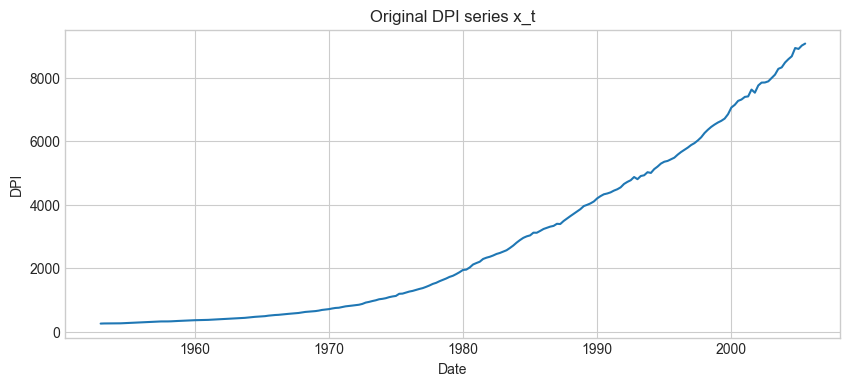

In [97]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x.index, x.values, color='tab:blue')
ax.set_title('Original DPI series x_t')
ax.set_xlabel('Date')
ax.set_ylabel('DPI')
plt.show()



x_t shows strong trend and level growth, so it is not stationary.


Part 2

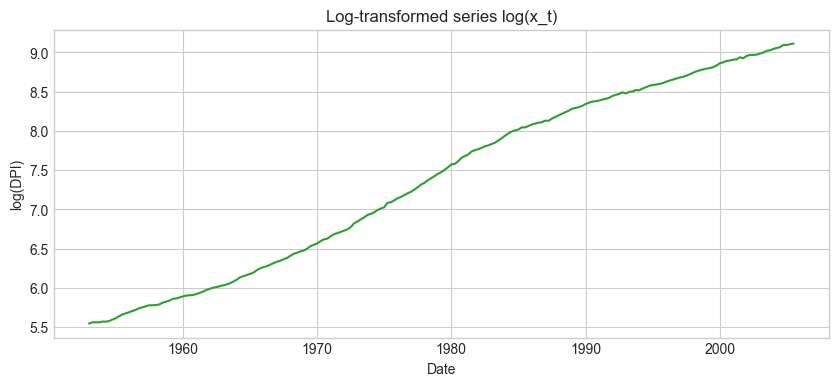

In [98]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(logx.index, logx.values, color='tab:green')
ax.set_title('Log-transformed series log(x_t)')
ax.set_xlabel('Date')
ax.set_ylabel('log(DPI)')
plt.show()



log transform stabilizes variance somewhat, but trend remains -> still nonstationary.


Part 3

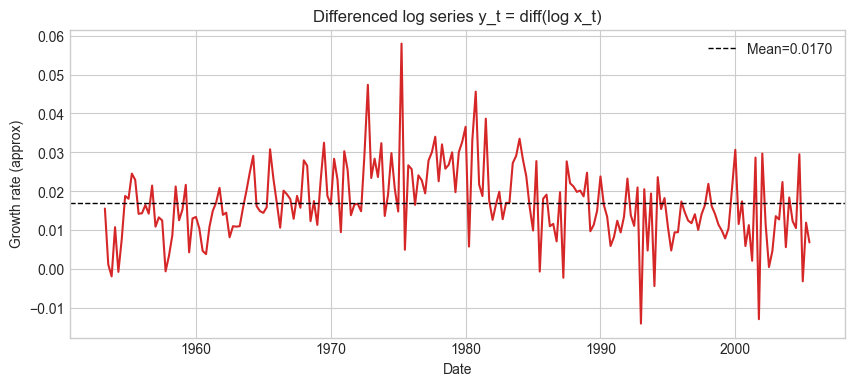

In [99]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y.index, y.values, color='tab:red')
ax.axhline(y.mean(), color='black', linestyle='--', linewidth=1, label=f'Mean={y.mean():.4f}')
ax.set_title('Differenced log series y_t = diff(log x_t)')
ax.set_xlabel('Date')
ax.set_ylabel('Growth rate (approx)')
ax.legend()
plt.show()

y_t fluctuates around a roughly constant mean and variance; this appears close to stationary.


Part 4

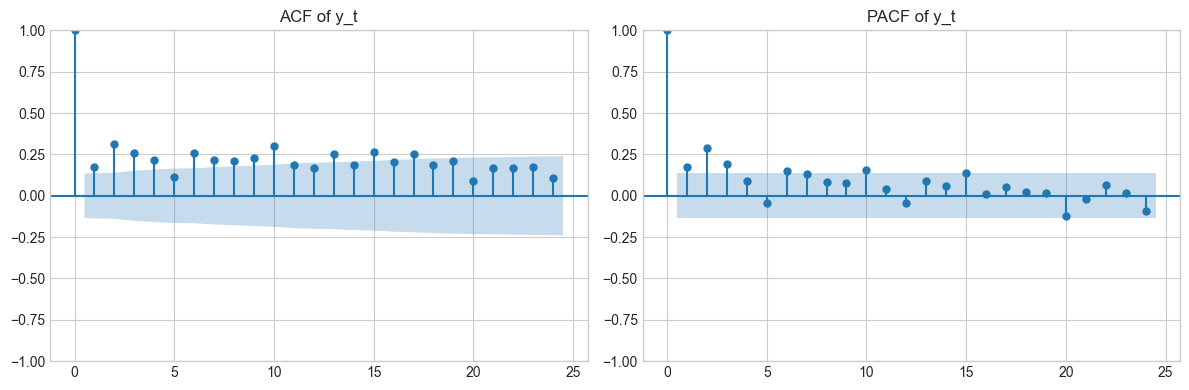

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y, lags=24, ax=axes[0])
plot_pacf(y, lags=24, ax=axes[1], method='ywm')
axes[0].set_title('ACF of y_t')
axes[1].set_title('PACF of y_t')
plt.tight_layout()
plt.show()


In [101]:
def eacf_like(series, max_ar=5, max_ma=5, acf_lags=24):
    from statsmodels.tsa.stattools import acf

    n = len(series)
    crit = 1.96 / np.sqrt(n)
    table = pd.DataFrame(index=[f'AR({p})' for p in range(max_ar + 1)],
                         columns=[f'MA({q})' for q in range(max_ma + 1)])

    for p in range(max_ar + 1):
        if p == 0:
            resid = series - np.mean(series)
        else:
            try:
                m = ARIMA(series, order=(p, 0, 0), trend='n').fit()
                resid = m.resid
            except Exception:
                table.loc[f'AR({p})', :] = 'NA'
                continue

        r = acf(resid, nlags=max(acf_lags, max_ma + 1), fft=False)
        for q in range(max_ma + 1):
            val = r[q + 1]
            table.loc[f'AR({p})', f'MA({q})'] = 'o' if abs(val) <= crit else 'x'

    return table

eacf_tbl = eacf_like(y, max_ar=5, max_ma=5)
print('EACF-like table (o = near-zero, x = significant):')
display(eacf_tbl)

tentative_models = [(1, 0, 1), (2, 0, 1), (1, 0, 2)]
print('Tentative models:', [f'ARMA({m[0]},{m[2]})' for m in tentative_models])


EACF-like table (o = near-zero, x = significant):


,MA(0),MA(1),MA(2),MA(3),MA(4),MA(5)
AR(0),x,x,x,x,o,x
AR(1),x,o,o,o,x,o
AR(2),x,x,o,o,x,o
AR(3),o,o,x,o,x,o
AR(4),o,o,o,x,x,o
AR(5),o,o,o,x,x,o


Tentative models: ['ARMA(1,1)', 'ARMA(2,1)', 'ARMA(1,2)']


Part 5

In [102]:
def rolling_one_step_mse(series, order, last_n=30):
    preds, actual = [], []
    n = len(series)
    for t in range(n - last_n, n):
        train = series.iloc[:t]
        target = series.iloc[t]
        try:
            fit = ARIMA(train, order=order, trend='n').fit()
            fc = fit.forecast(steps=1).iloc[0]
            preds.append(fc)
            actual.append(target)
        except Exception:
            preds.append(np.nan)
            actual.append(target)

    preds = np.array(preds, dtype=float)
    actual = np.array(actual, dtype=float)
    mask = np.isfinite(preds)
    return np.mean((actual[mask] - preds[mask]) ** 2)

results = {}
for order in tentative_models:
    name = f'ARMA({order[0]},{order[2]})'
    fit = ARIMA(y, order=order, trend='n').fit()

    table = pd.DataFrame({'estimate': fit.params, 'std_error': fit.bse})
    resid = fit.resid
    p, q = order[0], order[2]
    lb = acorr_ljungbox(resid, lags=[12], model_df=(p + q), return_df=True)
    mse30 = rolling_one_step_mse(y, order, last_n=30)

    results[name] = {'fit': fit, 'coef_table': table, 'resid': resid, 'ljung_box': lb, 'aic': fit.aic, 'mse30': mse30}

summary_rows = []
for name, r in results.items():
    summary_rows.append({'model': name, 'AIC': r['aic'], 'LjungBox_p_lag12': float(r['ljung_box']['lb_pvalue'].iloc[0]), 'Rolling_MSE_last30': r['mse30']})

model_summary = pd.DataFrame(summary_rows).sort_values('AIC').reset_index(drop=True)
model_summary


,model,AIC,LjungBox_p_lag12,Rolling_MSE_last30
0,"ARMA(2,1)",-1384.287842,0.243631,0.000097
1,"ARMA(1,1)",-1383.361525,0.171681,0.000102
2,"ARMA(1,2)",-1377.400952,0.092576,0.000098


ARMA(1,1)
- Coefficients and standard errors


,estimate,std_error
ar.L1,0.997781,0.003227
ma.L1,-0.899826,0.033390
sigma2,0.000078,0.000006


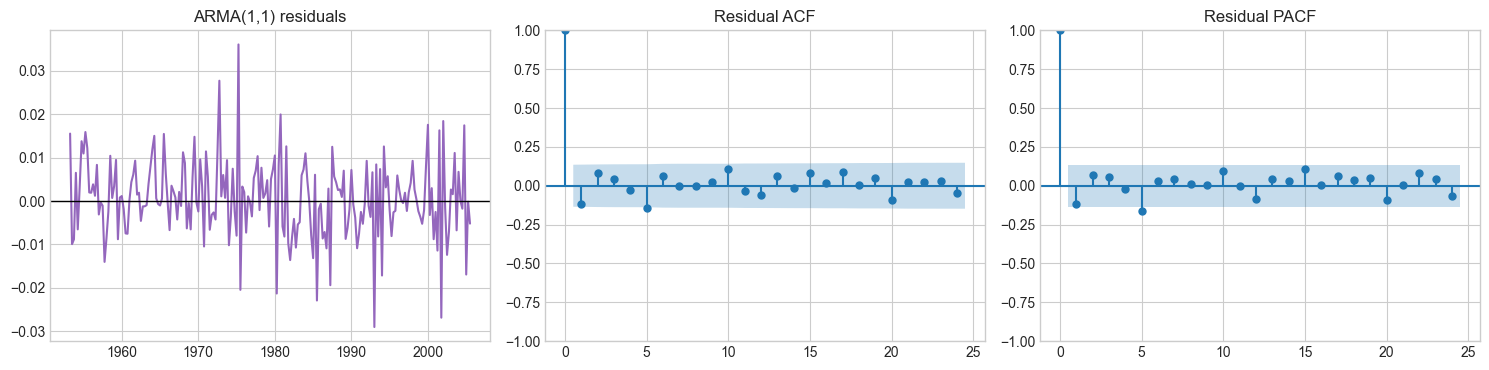

- Residual EACF-like table


,MA(0),MA(1),MA(2),MA(3),MA(4)
AR(0),o,o,o,o,x
AR(1),o,o,o,o,x
AR(2),o,o,o,o,x
AR(3),o,o,o,o,x
AR(4),o,o,o,o,x


- Box-Ljung test (lag 12, adjusted df = 12 - (p+q))


,lb_stat,lb_pvalue
12,14.028825,0.171681


- AIC: -1383.362
- Rolling one-step forecast MSE (last 30): 0.000102
ARMA(2,1)
- Coefficients and standard errors


,estimate,std_error
ar.L1,0.868702,0.069905
ar.L2,0.128547,0.070141
ma.L1,-0.878537,0.043839
sigma2,0.000076,0.000006


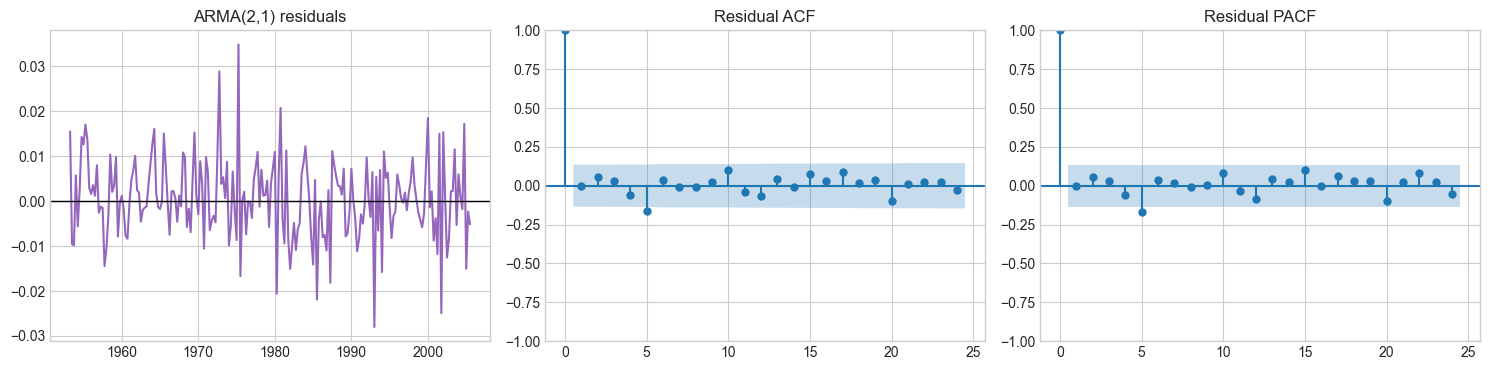

- Residual EACF-like table


,MA(0),MA(1),MA(2),MA(3),MA(4)
AR(0),o,o,o,o,x
AR(1),o,o,o,o,x
AR(2),o,o,o,o,x
AR(3),o,o,o,o,x
AR(4),o,o,o,o,x


- Box-Ljung test (lag 12, adjusted df = 12 - (p+q))


,lb_stat,lb_pvalue
12,11.489664,0.243631


- AIC: -1384.288
- Rolling one-step forecast MSE (last 30): 0.000097
ARMA(1,2)
- Coefficients and standard errors


,estimate,std_error
ar.L1,0.984888,0.007985
ma.L1,-0.940920,0.066874
ma.L2,0.118547,0.067508
sigma2,0.000079,0.000006


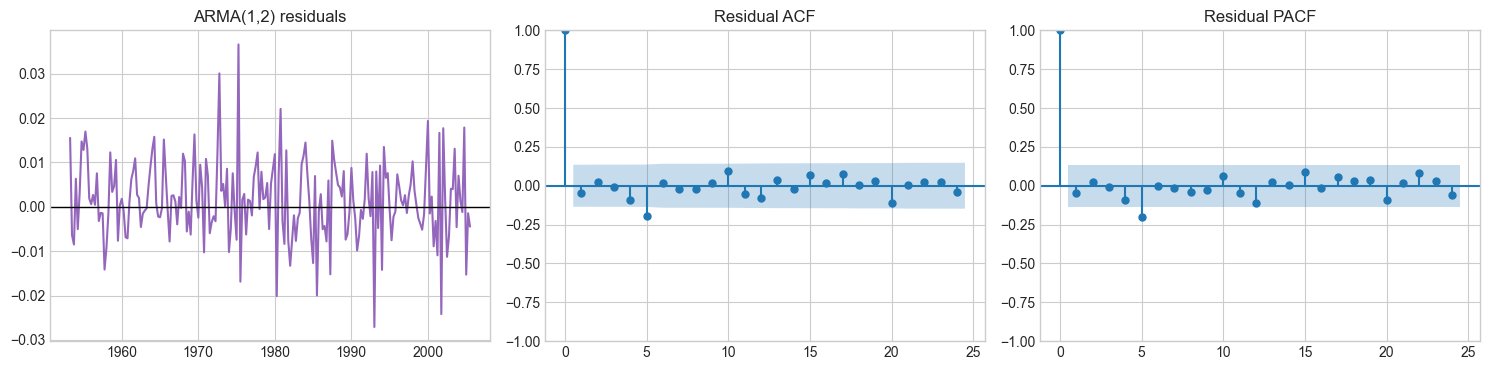

- Residual EACF-like table


,MA(0),MA(1),MA(2),MA(3),MA(4)
AR(0),o,o,o,o,x
AR(1),o,o,o,o,x
AR(2),o,o,o,o,x
AR(3),o,o,o,o,x
AR(4),o,o,o,o,x


- Box-Ljung test (lag 12, adjusted df = 12 - (p+q))


,lb_stat,lb_pvalue
12,14.940748,0.092576


- AIC: -1377.401
- Rolling one-step forecast MSE (last 30): 0.000098


In [103]:
for name, r in results.items():
    print('=' * 80)
    print(name)
    print('- Coefficients and standard errors')
    display(r['coef_table'])

    resid = r['resid']
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
    axes[0].plot(resid.index, resid.values, color='tab:purple')
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].set_title(f'{name} residuals')

    plot_acf(resid, lags=24, ax=axes[1])
    axes[1].set_title('Residual ACF')

    plot_pacf(resid, lags=24, ax=axes[2], method='ywm')
    axes[2].set_title('Residual PACF')

    plt.tight_layout()
    plt.show()

    print('- Residual EACF-like table')
    display(eacf_like(resid.dropna(), max_ar=4, max_ma=4))

    print('- Box-Ljung test (lag 12, adjusted df = 12 - (p+q))')
    display(r['ljung_box'])

    print(f"- AIC: {r['aic']:.3f}")
    print(f"- Rolling one-step forecast MSE (last 30): {r['mse30']:.6f}")


Part 6

In [104]:
best_by_aic = model_summary.iloc[0]['model']

print('Model comparison table:')
display(model_summary)

print(f"Selected best model: {best_by_aic}")


Model comparison table:


,model,AIC,LjungBox_p_lag12,Rolling_MSE_last30
0,"ARMA(2,1)",-1384.287842,0.243631,0.000097
1,"ARMA(1,1)",-1383.361525,0.171681,0.000102
2,"ARMA(1,2)",-1377.400952,0.092576,0.000098


Selected best model: ARMA(2,1)


ARMA(2,1) has the lowest AIC

Part 7

Disposable personal income is a really interesting macroeconomic indicator linked to household consumption and overall macroeconomic conditions. In this analysis, the original DPI level series and log-transformed series show trend and are not stationary, so we model the differenced log series $y_t=\Delta(\log x_t)$. After evaluating multiple ARMA candidates using ACF/PACF/EACF-style diagnostics, residual checks, Ljung-Box tests, AIC, and rolling one-step-ahead forecast MSE over the last 30 observations, it seems that the preferred model is ARMA(2,1), which had the best AIC among entertained models and reasonable residual diagnostics for short-term forecasting


## Problem 2


Value-weighted observations: 996


,ibmrtn,vwrtn,ewrtn,sprtn
date,,,,
1926-01-30,-0.010381,0.000724,0.023174,0.022472
1926-02-27,-0.024476,-0.033374,-0.053510,-0.043956
1926-03-31,-0.115591,-0.064341,-0.096824,-0.059113
1926-04-30,0.089783,0.038358,0.032946,0.022688
1926-05-28,0.036932,0.012172,0.001035,0.007679


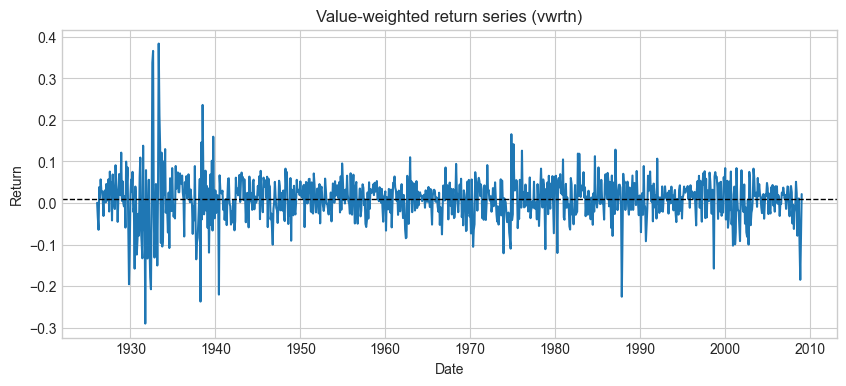

In [105]:
vw_path = Path('m-ibm3dx2608.txt')
vw = pd.read_csv(vw_path, sep=r'\s+')
vw['date'] = pd.to_datetime(vw['date'].astype(str), format='%Y%m%d')
vw = vw.sort_values('date').set_index('date')
vw_series = vw['vwrtn'].astype(float).dropna()

print(f'Value-weighted observations: {len(vw_series)}')
display(vw.head())

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(vw_series.index, vw_series.values, color='tab:blue')
ax.axhline(vw_series.mean(), color='black', linestyle='--', linewidth=1)
ax.set_title('Value-weighted return series (vwrtn)')
ax.set_xlabel('Date')
ax.set_ylabel('Return')
plt.show()


In [106]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fit_with_fixed_zeros(series, p, q, fixed_params=None):
    fixed_params = fixed_params or {}
    model = SARIMAX(series, order=(p, 0, q), trend='n',
                    enforce_stationarity=False, enforce_invertibility=False)
    if fixed_params:
        with model.fix_params(fixed_params):
            res = model.fit(disp=False)
    else:
        res = model.fit(disp=False)
    return res

def next_least_significant(res, fixed_params):
    free = []
    for name, val in res.pvalues.items():
        if (name.startswith('ar.L') or name.startswith('ma.L')) and (name not in fixed_params):
            free.append((name, float(val)))
    if not free:
        return None
    free.sort(key=lambda z: z[1], reverse=True)
    return free[0]

def simplify_by_zeroing(series, p, q, max_steps=20):
    fixed = {}
    history = []

    for step in range(max_steps):
        try:
            res = fit_with_fixed_zeros(series, p, q, fixed)
        except Exception:
            break

        lb = acorr_ljungbox(res.resid, lags=[12], model_df=(p + q - len(fixed)), return_df=True)
        history.append({
            'step': step,
            'fixed_count': len(fixed),
            'fixed': dict(fixed),
            'aic': float(res.aic),
            'lb_pvalue_lag12': float(lb['lb_pvalue'].iloc[0]),
            'result': res
        })

        nxt = next_least_significant(res, fixed)
        if nxt is None:
            break

        name, pval = nxt
        if pval < 0.05:
            break

        fixed[name] = 0.0

    return history

def history_table(history, label):
    rows = []
    for h in history:
        rows.append({
            'family': label,
            'step': h['step'],
            'fixed_count': h['fixed_count'],
            'AIC': h['aic'],
            'LjungBox_p_lag12': h['lb_pvalue_lag12'],
            'fixed_params': ', '.join(sorted(h['fixed'].keys())) if h['fixed'] else '(none)'
        })
    return pd.DataFrame(rows)


Part 1

In [107]:
ar_hist = simplify_by_zeroing(vw_series, p=9, q=0)
ar_tbl = history_table(ar_hist, 'AR from AR(9)')
display(ar_tbl)

best_ar = min(ar_hist, key=lambda h: h['aic'])
best_ar_res = best_ar['result']
print('Best AR candidate from simplification path:')
print(f"Step={best_ar['step']}, AIC={best_ar['aic']:.3f}, Ljung-Box p(12)={best_ar['lb_pvalue_lag12']:.4f}")
print('Fixed coefficients:', best_ar['fixed'] if best_ar['fixed'] else '(none)')
display(best_ar_res.summary())


,family,step,fixed_count,AIC,LjungBox_p_lag12,fixed_params
0,AR from AR(9),0,0,-2950.147877,0.527807,(none)
1,AR from AR(9),1,1,-2952.134850,0.712816,ar.L2
2,AR from AR(9),2,2,-2953.452455,0.678840,"ar.L2, ar.L6"
3,AR from AR(9),3,3,-2953.888333,0.651856,"ar.L2, ar.L6, ar.L7"
4,AR from AR(9),4,4,-2954.624775,0.703580,"ar.L2, ar.L4, ar.L6, ar.L7"


Best AR candidate from simplification path:
Step=4, AIC=-2954.625, Ljung-Box p(12)=0.7036
Fixed coefficients: {'ar.L2': 0.0, 'ar.L6': 0.0, 'ar.L7': 0.0, 'ar.L4': 0.0}


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  vwrtn   No. Observations:                  996
Model:               SARIMAX(9, 0, 0)   Log Likelihood                1483.312
Date:                Tue, 07 Apr 2026   AIC                          -2954.625
Time:                        15:41:09   BIC                          -2925.257
Sample:                             0   HQIC                         -2943.456
                                - 996                                         
Covariance Type:                  opg                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
ar.L1             0.1263      0.019      6.804      0.000       0.090       0.163
ar.L2 (fixed)          0        nan        nan        nan         nan         nan
ar.L3            -0.0867      0.022     -3.912      0.000      -0.130      -0.043
ar.L4 (fixed)          0        nan        nan        nan         nan         nan
ar.L5             0.0958      0.024      3.957      0.000       0.048       0.143
ar.L6 (fixed)          0        nan        nan        nan         nan         nan
ar.L7 (fixed)          0        nan        nan        nan         nan         nan
ar.L8             0.0684      0.021      3.253      0.001       0.027       0.110
ar.L9             0.0898      0.021      4.189      0.000       0.048       0.132
sigma2            0.0029   7.72e-05     37.562      0.000       0.003       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):              1464.56
Prob(Q):                              0.73   Prob(JB):                         0.00
Heteroskedasticity (H):               0.42   Skew:                             0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Part 2

In [108]:
ma_hist = simplify_by_zeroing(vw_series, p=0, q=9)
ma_tbl = history_table(ma_hist, 'MA from MA(9)')
display(ma_tbl)

best_ma = min(ma_hist, key=lambda h: h['aic'])
best_ma_res = best_ma['result']
print('Best MA candidate from simplification path:')
print(f"Step={best_ma['step']}, AIC={best_ma['aic']:.3f}, Ljung-Box p(12)={best_ma['lb_pvalue_lag12']:.4f}")
print('Fixed coefficients:', best_ma['fixed'] if best_ma['fixed'] else '(none)')
display(best_ma_res.summary())


,family,step,fixed_count,AIC,LjungBox_p_lag12,fixed_params
0,MA from MA(9),0,0,-2946.106103,0.466140,(none)
1,MA from MA(9),1,1,-2948.064053,0.654532,ma.L6
2,MA from MA(9),2,2,-2949.767164,0.829640,"ma.L4, ma.L6"
3,MA from MA(9),3,3,-2951.397842,0.915662,"ma.L2, ma.L4, ma.L6"
4,MA from MA(9),4,4,-2951.802761,0.926960,"ma.L2, ma.L4, ma.L6, ma.L7"


Best MA candidate from simplification path:
Step=4, AIC=-2951.803, Ljung-Box p(12)=0.9270
Fixed coefficients: {'ma.L6': 0.0, 'ma.L4': 0.0, 'ma.L2': 0.0, 'ma.L7': 0.0}


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  vwrtn   No. Observations:                  996
Model:               SARIMAX(0, 0, 9)   Log Likelihood                1481.901
Date:                Tue, 07 Apr 2026   AIC                          -2951.803
Time:                        15:41:11   BIC                          -2922.441
Sample:                             0   HQIC                         -2940.636
                                - 996                                         
Covariance Type:                  opg                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
ma.L1             0.1290      0.020      6.341      0.000       0.089       0.169
ma.L2 (fixed)          0        nan        nan        nan         nan         nan
ma.L3            -0.1025      0.023     -4.393      0.000      -0.148      -0.057
ma.L4 (fixed)          0        nan        nan        nan         nan         nan
ma.L5             0.1039      0.025      4.204      0.000       0.055       0.152
ma.L6 (fixed)          0        nan        nan        nan         nan         nan
ma.L7 (fixed)          0        nan        nan        nan         nan         nan
ma.L8             0.0414      0.018      2.263      0.024       0.006       0.077
ma.L9             0.1003      0.020      5.086      0.000       0.062       0.139
sigma2            0.0029   7.63e-05     37.943      0.000       0.003       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.17   Jarque-Bera (JB):              1469.34
Prob(Q):                              0.68   Prob(JB):                         0.00
Heteroskedasticity (H):               0.43   Skew:                             0.10
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.98
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Part 3

In [109]:
arma_hist = simplify_by_zeroing(vw_series, p=6, q=6)
arma_tbl = history_table(arma_hist, 'ARMA from ARMA(6,6)')
display(arma_tbl)

best_arma = min(arma_hist, key=lambda h: h['aic'])
best_arma_res = best_arma['result']
print('Best ARMA candidate from simplification path:')
print(f"Step={best_arma['step']}, AIC={best_arma['aic']:.3f}, Ljung-Box p(12)={best_arma['lb_pvalue_lag12']:.4f}")
print('Fixed coefficients:', best_arma['fixed'] if best_arma['fixed'] else '(none)')
display(best_arma_res.summary())


,family,step,fixed_count,AIC,LjungBox_p_lag12,fixed_params
0,"ARMA from ARMA(6,6)",0,0,-2953.840207,NaN,(none)
1,"ARMA from ARMA(6,6)",1,1,-2955.779605,0.038681,ar.L4
2,"ARMA from ARMA(6,6)",2,2,-2955.371960,0.030373,"ar.L4, ma.L4"
3,"ARMA from ARMA(6,6)",3,3,-2952.004172,0.058844,"ar.L2, ar.L4, ma.L4"
4,"ARMA from ARMA(6,6)",4,4,-2954.045379,0.123193,"ar.L2, ar.L4, ar.L6, ma.L4"
5,"ARMA from ARMA(6,6)",5,5,-2955.157829,0.179647,"ar.L2, ar.L4, ar.L6, ma.L4, ma.L6"
6,"ARMA from ARMA(6,6)",6,6,-2963.366503,0.145377,"ar.L2, ar.L4, ar.L5, ar.L6, ma.L4, ma.L6"
7,"ARMA from ARMA(6,6)",7,7,-2956.780969,0.193279,"ar.L2, ar.L4, ar.L5, ar.L6, ma.L2, ma.L4, ma.L6"


Best ARMA candidate from simplification path:
Step=6, AIC=-2963.367, Ljung-Box p(12)=0.1454
Fixed coefficients: {'ar.L4': 0.0, 'ma.L4': 0.0, 'ar.L2': 0.0, 'ar.L6': 0.0, 'ma.L6': 0.0, 'ar.L5': 0.0}


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  vwrtn   No. Observations:                  996
Model:               SARIMAX(6, 0, 6)   Log Likelihood                1488.683
Date:                Tue, 07 Apr 2026   AIC                          -2963.367
Time:                        15:41:19   BIC                          -2929.090
Sample:                             0   HQIC                         -2950.332
                                - 996                                         
Covariance Type:                  opg                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
ar.L1             0.5732      0.092      6.242      0.000       0.393       0.753
ar.L2 (fixed)          0        nan        nan        nan         nan         nan
ar.L3             0.4261      0.093      4.599      0.000       0.245       0.608
ar.L4 (fixed)          0        nan        nan        nan         nan         nan
ar.L5 (fixed)          0        nan        nan        nan         nan         nan
ar.L6 (fixed)          0        nan        nan        nan         nan         nan
ma.L1            -0.4557      0.438     -1.041      0.298      -1.314       0.402
ma.L2            -0.0608      0.264     -0.231      0.818      -0.577       0.456
ma.L3            -0.5458      0.302     -1.805      0.071      -1.138       0.047
ma.L4 (fixed)          0        nan        nan        nan         nan         nan
ma.L5             0.0623      0.042      1.477      0.140      -0.020       0.145
ma.L6 (fixed)          0        nan        nan        nan         nan         nan
sigma2            0.0029      0.001      2.002      0.045    6.05e-05       0.006
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              1829.18
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               0.41   Skew:                             0.16
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.65
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

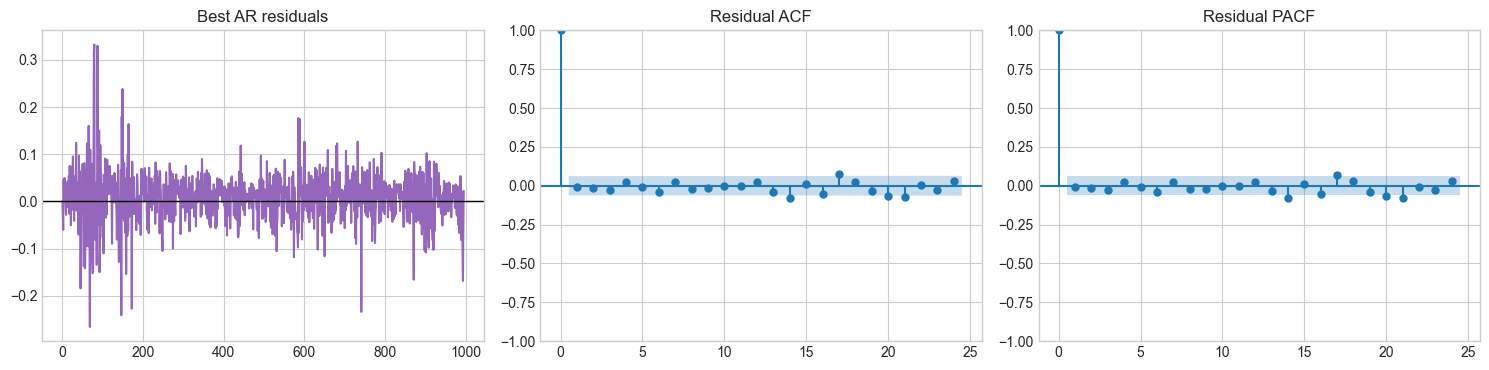

    lb_stat  lb_pvalue
12  4.64181   0.968886


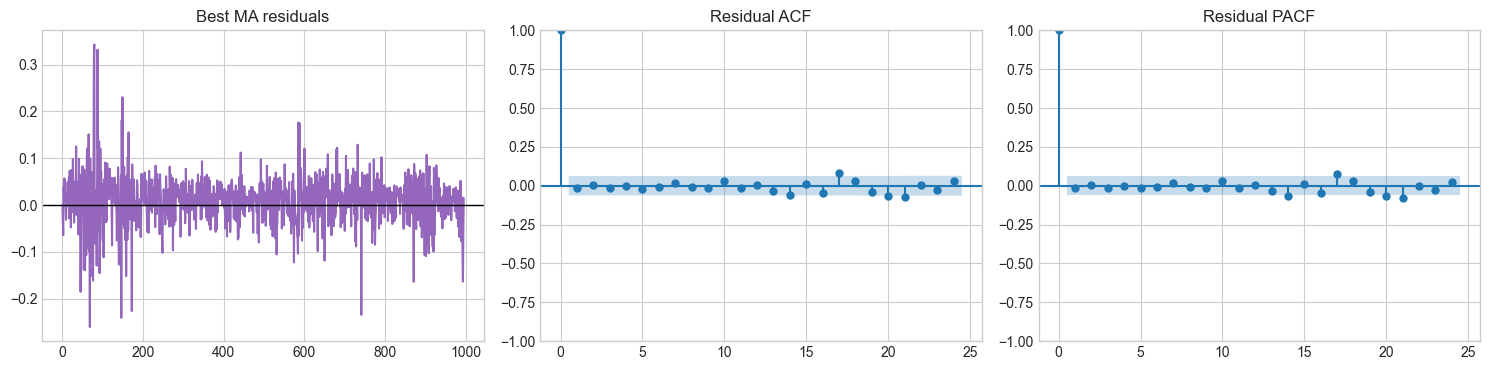

     lb_stat  lb_pvalue
12  2.501815   0.998155


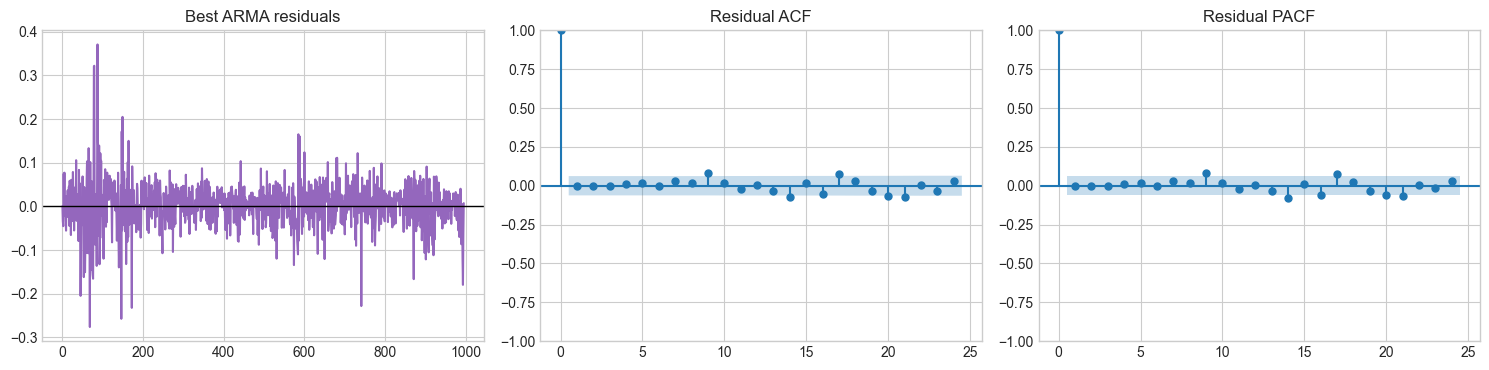

     lb_stat  lb_pvalue
12  9.540642   0.656189


In [110]:
def residual_diagnostics(res, title):
    resid = pd.Series(res.resid).dropna()
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
    axes[0].plot(resid.values, color='tab:purple')
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].set_title(f'{title} residuals')
    plot_acf(resid, lags=24, ax=axes[1])
    axes[1].set_title('Residual ACF')
    plot_pacf(resid, lags=24, ax=axes[2], method='ywm')
    axes[2].set_title('Residual PACF')
    plt.tight_layout()
    plt.show()

    print(acorr_ljungbox(resid, lags=[12], return_df=True))

residual_diagnostics(best_ar_res, 'Best AR')
residual_diagnostics(best_ma_res, 'Best MA')
residual_diagnostics(best_arma_res, 'Best ARMA')


From Lecture 05, hardcoding the models we covered:

vw.ar9.1: fixed=c(NA,0,NA,0,NA,0,0,NA,NA,NA)

vw.ma9.3: fixed=c(NA,0,NA,0,NA,0,0,0,NA,NA)

vw.66.1: fixed=c(NA,0,NA,NA,0,NA,NA,0,NA,NA,NA,NA,NA)

In [113]:
lecture_targets = pd.DataFrame([
    {'lecture_model':'vw.ar9.1','AIC_lecture':-3000.226,'Ljung_p_lecture':0.3667},
    {'lecture_model':'vw.ma9.3','AIC_lecture':-3005.032,'Ljung_p_lecture':0.5157},
    {'lecture_model':'vw.66.1','AIC_lecture':-3013.093,'Ljung_p_lecture':0.6979},
])


bench_specs = {
    'vw.ar9.1': {'p':9, 'q':0, 'fixed': {'ar.L2':0.0, 'ar.L4':0.0, 'ar.L6':0.0, 'ar.L7':0.0}},
    'vw.ma9.3': {'p':0, 'q':9, 'fixed': {'ma.L2':0.0, 'ma.L4':0.0, 'ma.L6':0.0, 'ma.L7':0.0, 'ma.L8':0.0}},
    'vw.66.1': {'p':6, 'q':6, 'fixed': {'ar.L2':0.0, 'ar.L5':0.0, 'ma.L2':0.0}},
}

bench_rows = []
for name, spec in bench_specs.items():
    model = SARIMAX(vw_series, order=(spec['p'], 0, spec['q']), trend='c',
                    enforce_stationarity=False, enforce_invertibility=False)
    with model.fix_params(spec['fixed']):
        fit = model.fit(disp=False)

    lb = acorr_ljungbox(fit.resid, lags=[18], model_df=(spec['p'] + spec['q'] - len(spec['fixed'])), return_df=True)
    bench_rows.append({
        'lecture_model': name,
        'AIC_reproduced': float(fit.aic),
        'Ljung_p_reproduced_lag18': float(lb['lb_pvalue'].iloc[0]),
        'fixed_params': ', '.join(sorted(spec['fixed'].keys()))
    })

bench_df = pd.DataFrame(bench_rows)
compare_lecture = lecture_targets.merge(bench_df, on='lecture_model', how='left')
compare_lecture['AIC_diff_reproduced_minus_lecture'] = compare_lecture['AIC_reproduced'] - compare_lecture['AIC_lecture']
compare_lecture['Ljung_diff_reproduced_minus_lecture'] = compare_lecture['Ljung_p_reproduced_lag18'] - compare_lecture['Ljung_p_lecture']
display(compare_lecture)

my_best = pd.DataFrame([
    {'model':'Best AR','AIC_my':best_ar['aic']},
    {'model':'Best MA','AIC_my':best_ma['aic']},
    {'model':'Best ARMA','AIC_my':best_arma['aic']},
])
display(my_best)


,lecture_model,AIC_lecture,Ljung_p_lecture,AIC_reproduced,Ljung_p_reproduced_lag18,fixed_params,AIC_diff_reproduced_minus_lecture,Ljung_diff_reproduced_minus_lecture
0,vw.ar9.1,-3000.226,0.3667,-2967.738436,0.112375,"ar.L2, ar.L4, ar.L6, ar.L7",32.487564,-0.254325
1,vw.ma9.3,-3005.032,0.5157,-2969.138383,0.252658,"ma.L2, ma.L4, ma.L6, ma.L7, ma.L8",35.893617,-0.263042
2,vw.66.1,-3013.093,0.6979,-2963.374960,0.006334,"ar.L2, ar.L5, ma.L2",49.718040,-0.691566


,model,AIC_my
0,Best AR,-2954.624775
1,Best MA,-2951.802761
2,Best ARMA,-2963.366503


In [114]:
compare = pd.DataFrame([
    {'model':'Best AR (from AR9 path)','AIC':best_ar['aic'],'LjungBox_p_lag12':best_ar['lb_pvalue_lag12'],'fixed':str(best_ar['fixed'])},
    {'model':'Best MA (from MA9 path)','AIC':best_ma['aic'],'LjungBox_p_lag12':best_ma['lb_pvalue_lag12'],'fixed':str(best_ma['fixed'])},
    {'model':'Best ARMA (from 6,6 path)','AIC':best_arma['aic'],'LjungBox_p_lag12':best_arma['lb_pvalue_lag12'],'fixed':str(best_arma['fixed'])},
]).sort_values('AIC').reset_index(drop=True)
display(compare)

,model,AIC,LjungBox_p_lag12,fixed
0,"Best ARMA (from 6,6 path)",-2963.366503,0.145377,"{'ar.L4': 0.0, 'ma.L4': 0.0, 'ar.L2': 0.0, 'ar..."
1,Best AR (from AR9 path),-2954.624775,0.703580,"{'ar.L2': 0.0, 'ar.L6': 0.0, 'ar.L7': 0.0, 'ar..."
2,Best MA (from MA9 path),-2951.802761,0.926960,"{'ma.L6': 0.0, 'ma.L4': 0.0, 'ma.L2': 0.0, 'ma..."


For Problem 2, I started with AR(9), MA(9), and ARMA(6,6), and then simplified each model step by step by setting the least significant coefficient to zero and refitting. After each change, I checked AIC and residual diagnostics (Ljung-Box plus residual ACF/PACF) to make sure the model still looked reasonable. I also compared my simplified models to the lecture versions (`vw.ar9.1`, `vw.ma9.3`, and `vw.66.1`) -- hardcoded those based on the lecture html from Canvas 

My main finding is that simplification helped across all three parts: removing weak terms kept residuals acceptable, and generally got better AIC than the unsimplified starting models. The strongest overall result came from the ARMA(6,6)-based simplification, which matches the lecture takeaway that the constrained ARMA model is the best of the three. My exact numbers are a little different from lecture because I used Python/statsmodels instead of R, but the overall conclusion is the same.
